In [1]:
# Import necessary packages
import warnings
import pandas as pd
import numpy as np
import string
import re
import pickle
import time
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLP-related imports
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Scikit-learn imports for model evaluation and preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (f1_score, accuracy_score, precision_score, 
                             recall_score, roc_curve, auc, confusion_matrix)

# PyTorch imports for building and training neural networks
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Data processing imports from torchtext (if needed)
from transformers import AutoTokenizer # For loading a pre-trained tokenizer

# Suppress specific warnings
warnings.filterwarnings("ignore", message=r".*datetime\.datetime\.utcnow.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
df_sent = pd.read_csv('sentiment_prep.csv')

In [ ]:
df_sent = df_sent.dropna(subset=["review_text"])

In [ ]:
train, test = train_test_split(
    df_sent,
    test_size=0.2,    # 20% of data for testing
    random_state=42,  # for reproducible splits
    shuffle=True      # ensures random distribution
)

In [ ]:
train.head()

In [ ]:
test.head()

In [ ]:
def remove_urls(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub(r'', text)

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

def remove_numbers(text):
    return re.sub(r'\d+', '', text) 

def remove_nonsensical(text):
    return text.replace('\n', ' ').replace('\r', ' ')

#Dictionary for converting emoticons
EMOTICONS = {
    r":‑\)": "Happy face or smiley",
    r":\)": "Happy face or smiley",
    r":-\]": "Happy face or smiley",
    r":\]": "Happy face or smiley",
    r":-3": "Happy face smiley",
    r":3": "Happy face smiley",
    r":->": "Happy face smiley",
    r":>": "Happy face smiley",
    r"8-\)": "Happy face smiley",
    r":o\)": "Happy face smiley",
    r":-\}": "Happy face smiley",
    r":\}": "Happy face smiley",
    r":-\)": "Happy face smiley",
    r":c\)": "Happy face smiley",
    r":\^\)": "Happy face smiley",
    r"=\]": "Happy face smiley",
    r"=\)": "Happy face smiley",
    r":‑D": "Laughing, big grin or laugh with glasses",
    r":D": "Laughing, big grin or laugh with glasses",
    r"8‑D": "Laughing, big grin or laugh with glasses",
    r"8D": "Laughing, big grin or laugh with glasses",
    r"X‑D": "Laughing, big grin or laugh with glasses",
    r"XD": "Laughing, big grin or laugh with glasses",
    r"=D": "Laughing, big grin or laugh with glasses",
    r"=3": "Laughing, big grin or laugh with glasses",
    r"B\^D": "Laughing, big grin or laugh with glasses",
    r":-\)\)": "Very happy",
    r":‑\(": "Frown, sad, andry or pouting",
    r":-\(": "Frown, sad, andry or pouting",
    r":\(": "Frown, sad, andry or pouting",
    r":‑c": "Frown, sad, andry or pouting",
    r":c": "Frown, sad, andry or pouting",
    r":‑<": "Frown, sad, andry or pouting",
    r":<": "Frown, sad, andry or pouting",
    r":‑\[": "Frown, sad, andry or pouting",
    r":\[": "Frown, sad, andry or pouting",
    r":-\|\|": "Frown, sad, andry or pouting",
    r">:\[": "Frown, sad, andry or pouting",
    r":\{": "Frown, sad, andry or pouting",
    r":@": "Frown, sad, andry or pouting",
    r">:\(": "Frown, sad, andry or pouting",
    r":'‑\(": "Crying",
    r":'\(": "Crying",
    r":'‑\)": "Tears of happiness",
    r":'\)": "Tears of happiness",
    r"D‑':": "Horror",
    r"D:<": "Disgust",
    r"D:": "Sadness",
    r"D8": "Great dismay",
    r"D;": "Great dismay",
    r"D=": "Great dismay",
    r"DX": "Great dismay",
    r":‑O": "Surprise",
    r":O": "Surprise",
    r":‑o": "Surprise",
    r":o": "Surprise",
    r":-0": "Shock",
    r"8‑0": "Yawn",
    r">:O": "Yawn",
    r":-\*": "Kiss",
    r":\*": "Kiss",
    r":X": "Kiss",
    r";‑\)": "Wink or smirk",
    r";\)": "Wink or smirk",
    r"\*-\)": "Wink or smirk",
    r"\*\)": "Wink or smirk",
    r";‑\]": "Wink or smirk",
    r";\]": "Wink or smirk",
    r";\^\)": "Wink or smirk",
    r":‑,": "Wink or smirk",
    r";D": "Wink or smirk",
    r":‑P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"X‑P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"XP": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":‑Þ": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":Þ": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":b": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"d:": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"=p": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r">:P": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r":‑/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":-[.]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r">:[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r">:/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=/": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=[(\\\)]": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":L": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r"=L": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":S": "Skeptical, annoyed, undecided, uneasy or hesitant",
    r":‑\|": "Straight face",
    r":\|": "Straight face",
    r":$": "Embarrassed or blushing",
    r":‑x": "Sealed lips or wearing braces or tongue-tied",
    r":x": "Sealed lips or wearing braces or tongue-tied",
    r":‑#": "Sealed lips or wearing braces or tongue-tied",
    r":#": "Sealed lips or wearing braces or tongue-tied",
    r":‑&": "Sealed lips or wearing braces or tongue-tied",
    r":&": "Sealed lips or wearing braces or tongue-tied",
    r"O:‑\)": "Angel, saint or innocent",
    r"O:\)": "Angel, saint or innocent",
    r"0:‑3": "Angel, saint or innocent",
    r"0:3": "Angel, saint or innocent",
    r"0:‑\)": "Angel, saint or innocent",
    r"0:\)": "Angel, saint or innocent",
    r":‑b": "Tongue sticking out, cheeky, playful or blowing a raspberry",
    r"0;\^\)": "Angel, saint or innocent",
    r">:‑\)": "Evil or devilish",
    r">:\)": "Evil or devilish",
    r"\}:‑\)": "Evil or devilish",
    r"\}:\)": "Evil or devilish",
    r"3:‑\)": "Evil or devilish",
    r"3:\)": "Evil or devilish",
    r">;\)": "Evil or devilish",
    r"\|;‑\)": "Cool",
    r"\|‑O": "Bored",
    r":‑J": "Tongue-in-cheek",
    r"#‑\)": "Party all night",
    r"%‑\)": "Drunk or confused",
    r"%\)": "Drunk or confused",
    r":-###..": "Being sick",
    r":###..": "Being sick",
    r"<:‑\|": "Dump",
    r"\(>_<\)": "Troubled",
    r"\(>_<\)>": "Troubled",
    r"\(';'\)": "Baby",
    r"\(\^\^>``": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(\^_\^;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(-_-;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(~_~;\) \(・\.・;\)": "Nervous or Embarrassed or Troubled or Shy or Sweat drop",
    r"\(-_-\)zzz": "Sleeping",
    r"\(\^_-\)": "Wink",
    r"\(\(\+_\+\)\)": "Confused",
    r"\(\+o\+\)": "Confused",
    r"\(o\|o\)": "Ultraman",
    r"\^_\^": "Joyful",
    r"\(\^_\^\)/": "Joyful",
    r"\(\^O\^\)／": "Joyful",
    r"\(\^o\^\)／": "Joyful",
    r"\(__\)": "Kowtow as a sign of respect, or dogeza for apology",
    r"_\(\._\.\)_": "Kowtow as a sign of respect, or dogeza for apology",
    r"<\(_ _\)>": "Kowtow as a sign of respect, or dogeza for apology",
    r"<m\(__\)m>": "Kowtow as a sign of respect, or dogeza for apology",
    r"m\(__\)m": "Kowtow as a sign of respect, or dogeza for apology",
    r"m\(_ _\)m": "Kowtow as a sign of respect, or dogeza for apology",
    r"\('_'\)": "Sad or Crying",
    r"\(/_;\)": "Sad or Crying",
    r"\(T_T\) \(;_;\)": "Sad or Crying",
    r"\(;_;": "Sad of Crying",
    r"\(;_:\)": "Sad or Crying",
    r"\(;O;\)": "Sad or Crying",
    r"\(:_;\)": "Sad or Crying",
    r"\(ToT\)": "Sad or Crying",
    r";_;": "Sad or Crying",
    r";-;": "Sad or Crying",
    r";n;": "Sad or Crying",
    r";;": "Sad or Crying",
    r"Q\.Q": "Sad or Crying",
    r"T\.T": "Sad or Crying",
    r"QQ": "Sad or Crying",
    r"Q_Q": "Sad or Crying",
    r"\(-\.-\)": "Shame",
    r"\(-_-\)": "Shame",
    r"\(一一\)": "Shame",
    r"\(；一_一\)": "Shame",
    r"\(=_=\)": "Tired",
    r"\(=\^\·\^=\)": "cat",
    r"\(=\^\·\·\^=\)": "cat",
    r"=_\^=": "cat",
    r"\(\.\.\)": "Looking down",
    r"\(\._\.\)": "Looking down",
    r"\^m\^": "Giggling with hand covering mouth",
    r"\(\・\・?": "Confusion",
    r"\(?_?\)": "Confusion",
    r">\^_\^<": "Normal Laugh",
    r"<\^!\^>": "Normal Laugh",
    r"\^/\^": "Normal Laugh",
    r"\（\*\^_\^\*）": "Normal Laugh",
    r"\(\^<\^\) \(\^\.\^\)": "Normal Laugh",
    r"\(^\^\)": "Normal Laugh",
    r"\(\^\.\^\)": "Normal Laugh",
    r"\(\^_\^\.\)": "Normal Laugh",
    r"\(\^_\^\)": "Normal Laugh",
    r"\(\^\^\)": "Normal Laugh",
    r"\(\^J\^\)": "Normal Laugh",
    r"\(\*\^\.\^\*\)": "Normal Laugh",
    r"\(\^—\^\）": "Normal Laugh",
    r"\(#\^\.\^#\)": "Normal Laugh",
    r"\（\^—\^\）": "Waving",
    r"\(;_;\)/~~~": "Waving",
    r"\(\^\.\^\)/~~~": "Waving",
    r"\(-_-\)/~~~ \($\·\·\)/~~~": "Waving",
    r"\(T_T\)/~~~": "Waving",
    r"\(ToT\)/~~~": "Waving",
    r"\(\*\^0\^\*\)": "Excited",
    r"\(\*_\*\)": "Amazed",
    r"\(\*_\*;": "Amazed",
    r"\(\+_\+\) \(@_@\)": "Amazed",
    r"\(\*\^\^\)v": "Laughing,Cheerful",
    r"\(\^_\^\)v": "Laughing,Cheerful",
    r"\(\(d[-_-]b\)\)": "Headphones,Listening to music",
    r'\(-"-\)': "Worried",
    r"\(ーー;\)": "Worried",
    r"\(\^0_0\^\)": "Eyeglasses",
    r"\(\＾ｖ\＾\)": "Happy",
    r"\(\＾ｕ\＾\)": "Happy",
    r"\(\^\)o\(\^\)": "Happy",
    r"\(\^O\^\)": "Happy",
    r"\(\^o\^\)": "Happy",
    r"\)\^o\^\(": "Happy",
    r":O o_O": "Surprised",
    r"o_0": "Surprised",
    r"o\.O": "Surprised",
    r"\(o\.o\)": "Surprised",
    r"oO": "Surprised",
    r"\(\*￣m￣\)": "Dissatisfied",
    r"\(‘A`\)": "Snubbed or Deflated"}

In [ ]:
def convert_emoticons(text):
    for emot in EMOTICONS:
        text = re.sub(u'('+emot+')', "_".join(EMOTICONS[emot].replace(",","").split()), text)
    return text

def remove_stopwords(text):
    return " ".join([word for word in str(text).split() if word not in STOPWORDS])

def remove_freqwords(text):
    return " ".join([word for word in str(text).split() if word not in FREQWORDS])

def remove_rarewords(text):
    return " ".join([word for word in str(text).split() if word not in RAREWORDS])


def stem_words(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

def lemmatize_words(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

In [ ]:
# Convert the training set
train["review_text"] = train["review_text"].str.lower()
train["review_text"] = train["review_text"].apply(lambda text: remove_urls(text))
PUNCT_TO_REMOVE = string.punctuation
train["review_text"] = train["review_text"].apply(lambda text: remove_punctuation(text))
train["review_text"] = train["review_text"].apply(lambda text: remove_numbers(text))
train["review_text"] = train["review_text"].apply(lambda text: remove_nonsensical(text))
train["review_text"] = train["review_text"].apply(lambda text: convert_emoticons(text))
STOPWORDS = set(stopwords.words('english'))
train["review_text"] = train["review_text"].apply(lambda text: remove_stopwords(text))
cnt = Counter()
for text in train["review_text"].values:
    for word in text.split():
        cnt[word] += 1     
FREQWORDS = set([w for (w, wc) in cnt.most_common(10)])
train["review_text"] = train["review_text"].apply(lambda text: remove_freqwords(text))
n_rare_words = 10
RAREWORDS = set([w for (w, wc) in cnt.most_common()[:-n_rare_words-1:-1]])
train["review_text"] = train["review_text"].apply(lambda text: remove_rarewords(text))
stemmer = PorterStemmer()
train["review_text"] = train["review_text"].apply(lambda text: stem_words(text))
lemmatizer = WordNetLemmatizer()
train["review_text"] = train["review_text"].apply(lambda text: lemmatize_words(text))
train.head()

In [ ]:
#save the converted training set
train_clean = train.copy()
train_clean.to_pickle('train_clean.pkl')

In [ ]:
# Convert the test set
test["review_text"] = test["review_text"].str.lower()
test["review_text"] = test["review_text"].apply(lambda text: remove_urls(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_punctuation(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_numbers(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_nonsensical(text))
test["review_text"] = test["review_text"].apply(lambda text: convert_emoticons(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_stopwords(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_freqwords(text))
test["review_text"] = test["review_text"].apply(lambda text: remove_rarewords(text))

test["review_text"] = test["review_text"].apply(lambda text: stem_words(text))
test["review_text"] = test["review_text"].apply(lambda text: lemmatize_words(text))

test.head()

In [ ]:
test_clean = test.copy()
test_clean.to_pickle('test_clean.pkl')

In [ ]:
train_clean= pd.read_pickle('train_clean.pkl')
test_clean= pd.read_pickle('test_clean.pkl')

In [ ]:
print(train_clean.head())

In [ ]:
print(test_clean.head())

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from tqdm import tqdm

model_name = "facebook/nllb-200-distilled-600M"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSeq2SeqLM.from_pretrained(model_name, use_safetensors=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


def batch_translate(texts, batch_size=16):
    translated_texts = []
    
    try:
        tgt_lang_id = tokenizer.convert_tokens_to_ids("eng_Latn")
    except:
        tgt_lang_id = tokenizer.lang_code_to_id["eng_Latn"]

    for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
        batch = texts[i : i + batch_size].fillna("").astype(str).tolist()
        
        inputs = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
        
        with torch.no_grad():
            outputs = model.generate(
                **inputs, 
                forced_bos_token_id=tgt_lang_id,
                max_new_tokens=128
            )
        
        decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        translated_texts.extend(decoded)
        
    return translated_texts

test_subset = train_clean['review_text'].head(100)
train_clean.loc[test_subset.index, 'english_review_text'] = batch_translate(test_subset)

print(train_clean[['review_text', 'english_review_text']].head())


In [ ]:
train_clean.head()

In [ ]:
# 1. Translate the Training Set (approx. 31,000+ records)
print(f"Starting translation for the Training Set: {len(train_clean)} records...")
# Using batch_size=32 for better performance; reduce to 16 if memory issues occur
train_clean['english_review_text'] = batch_translate(train_clean['review_text'], batch_size=32)

# Save Training Set to CSV immediately
train_clean.to_csv("train_translated_final.csv", index=False)
print("✅ Training Set translation complete! Saved as 'train_translated_final.csv'")

# 2. Translate the Test Set (approx. 5,000+ records)
print(f"\nStarting translation for the Test Set: {len(test_clean)} records...")
test_clean['english_review_text'] = batch_translate(test_clean['review_text'], batch_size=32)

# Save Test Set to CSV immediately
test_clean.to_csv("test_translated_final.csv", index=False)
print("✅ Test Set translation complete! Saved as 'test_translated_final.csv'")

# Final Preview
print("\n--- Final Results Preview ---")
print("Train Set (Head):\n", train_clean[['review_text', 'english_review_text']].head())
print("\nTest Set (Head):\n", test_clean[['review_text', 'english_review_text']].head())

In [2]:
train_clean = pd.read_csv('train_translated_final.csv')
test_clean = pd.read_csv('test_translated_final.csv')

In [3]:
print(train_clean.head())

                           order_id  review_score  \
0  f585ab48a4d0027744dd2912cb42a2cb             1   
1  01a1553cddb473cec004af5ce2192f1c             4   
2  57274b4596c5c76c54168e88dbcf922f             5   
3  027a84a16c22c706669f35d578853f3e             1   
4  5c2bbf0c34b51eec1e79c0d7ef81f86b             5   

                                         review_text  \
0                                    veio pwla metad   
1                                              otimo   
2   luminária linda boa qualidad chegou bem embalada   
3  quero saber porqu tanto atraso na minha encome...   
4  ótima compra qualidad excelent valor melhor ai...   

                 customer_unique_id                         review_id  \
0  919b613e7aa171cb4ca017c049fbc5da  2f210df09863168e9f9372e43ce53528   
1  704c21a02e59001049f14ec33b3b0be0  bb4adccbf5dec1dc01a9fadb2fe3a6bf   
2  a7175616bbd961493941fa1159d2033f  61364556967b7fbdbda6a7a71573ce70   
3  5250c9708a2b44c10bd5cd9f94235290  bc99e8911baf06b

C:\Users\user\AppData\Local\Temp\ipykernel_3472\3234027038.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_stats.index, y=category_stats.values, palette='viridis')


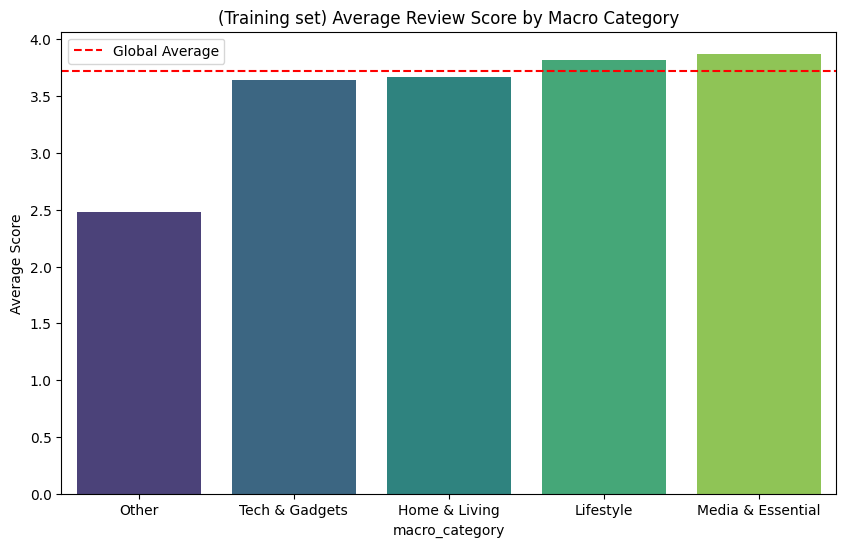

In [4]:
category_stats = train_clean.groupby('macro_category')['review_score'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=category_stats.index, y=category_stats.values, palette='viridis')
plt.title('(Training set) Average Review Score by Macro Category')
plt.ylabel('Average Score')
plt.axhline(train_clean['review_score'].mean(), color='red', linestyle='--', label='Global Average')
plt.legend()
plt.show()

In [5]:
category_counts = train_clean['macro_category'].value_counts()
print(category_counts)

macro_category
Home & Living        11978
Lifestyle            10157
Tech & Gadgets        7049
Media & Essential     2099
Other                   29
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_3472\922363590.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_stats.index, y=category_stats.values, palette='viridis')


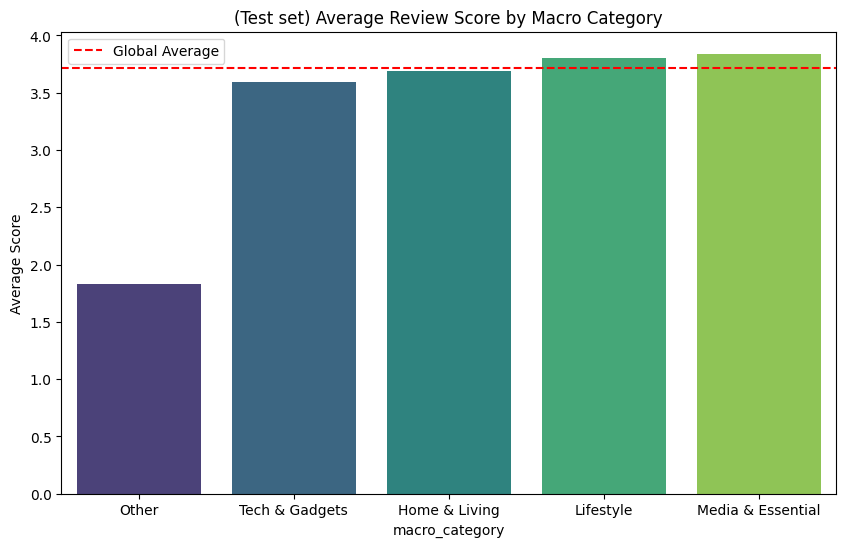

In [6]:
category_stats = test_clean.groupby('macro_category')['review_score'].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=category_stats.index, y=category_stats.values, palette='viridis')
plt.title('(Test set) Average Review Score by Macro Category')
plt.ylabel('Average Score')
plt.axhline(test_clean['review_score'].mean(), color='red', linestyle='--', label='Global Average')
plt.legend()
plt.show()

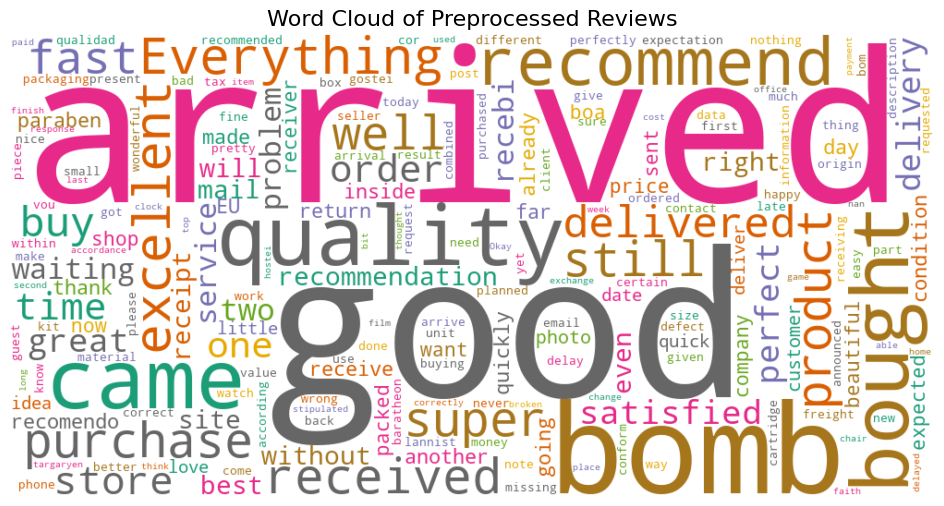

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_cleaned_text = " ".join(text for text in train_clean['english_review_text'].astype(str))


wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    max_words=200,       
    colormap='Dark2',       
    collocations=False     
).generate(all_cleaned_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Preprocessed Reviews', fontsize=16)
plt.show()

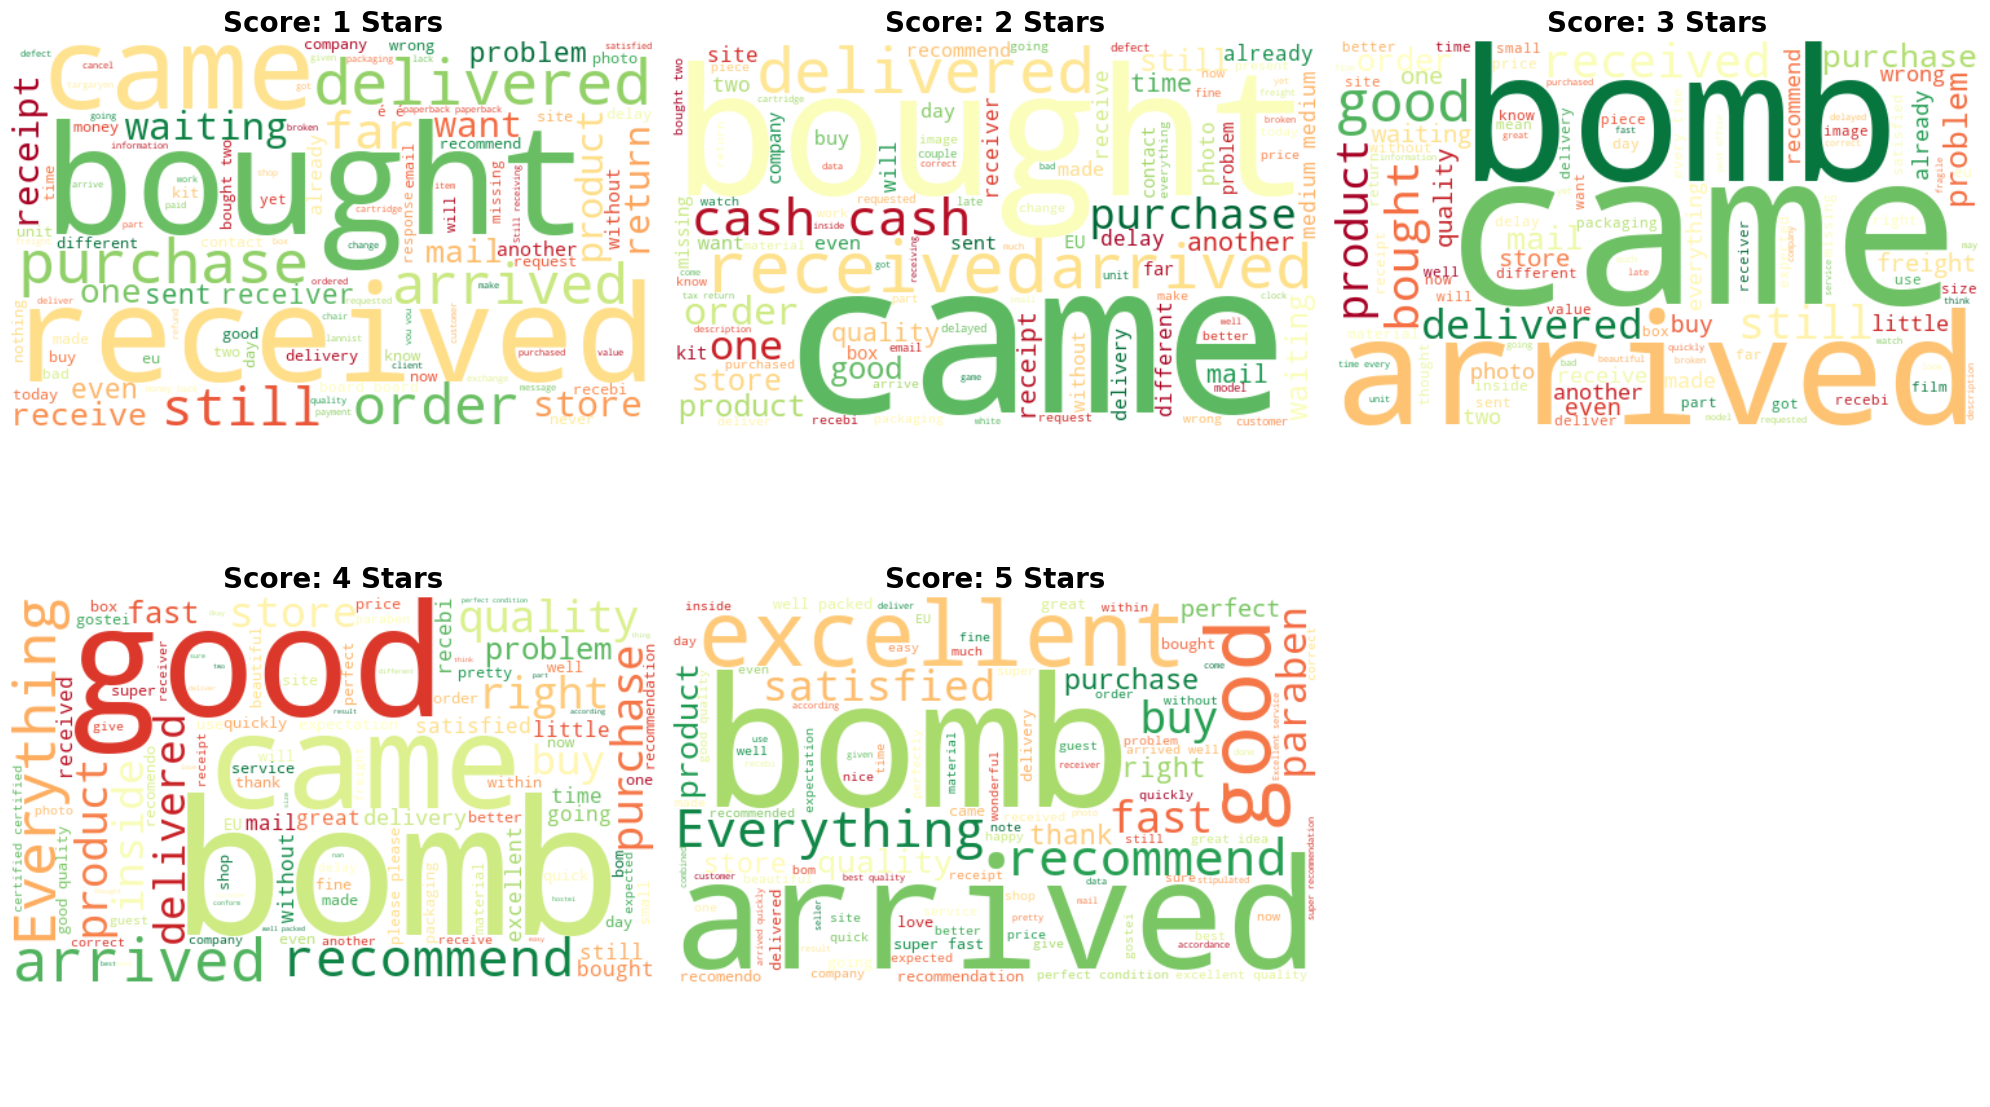

In [8]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, score in enumerate([1, 2, 3, 4, 5]):
    subset = train_clean[train_clean['review_score'] == score]
    
    text = " ".join(review for review in subset['english_review_text'].astype(str))
    
    if len(text.strip()) > 0:
        wc = WordCloud(
            width=500, 
            height=300, 
            background_color='white',
            max_words=100,
            colormap='RdYlGn'
        ).generate(text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'Score: {score} Stars', fontsize=20, fontweight='bold')
    else:
        axes[i].text(0.5, 0.5, 'No Data', ha='center')
        
    axes[i].axis('off')

axes[5].axis('off')

plt.tight_layout()
plt.show()

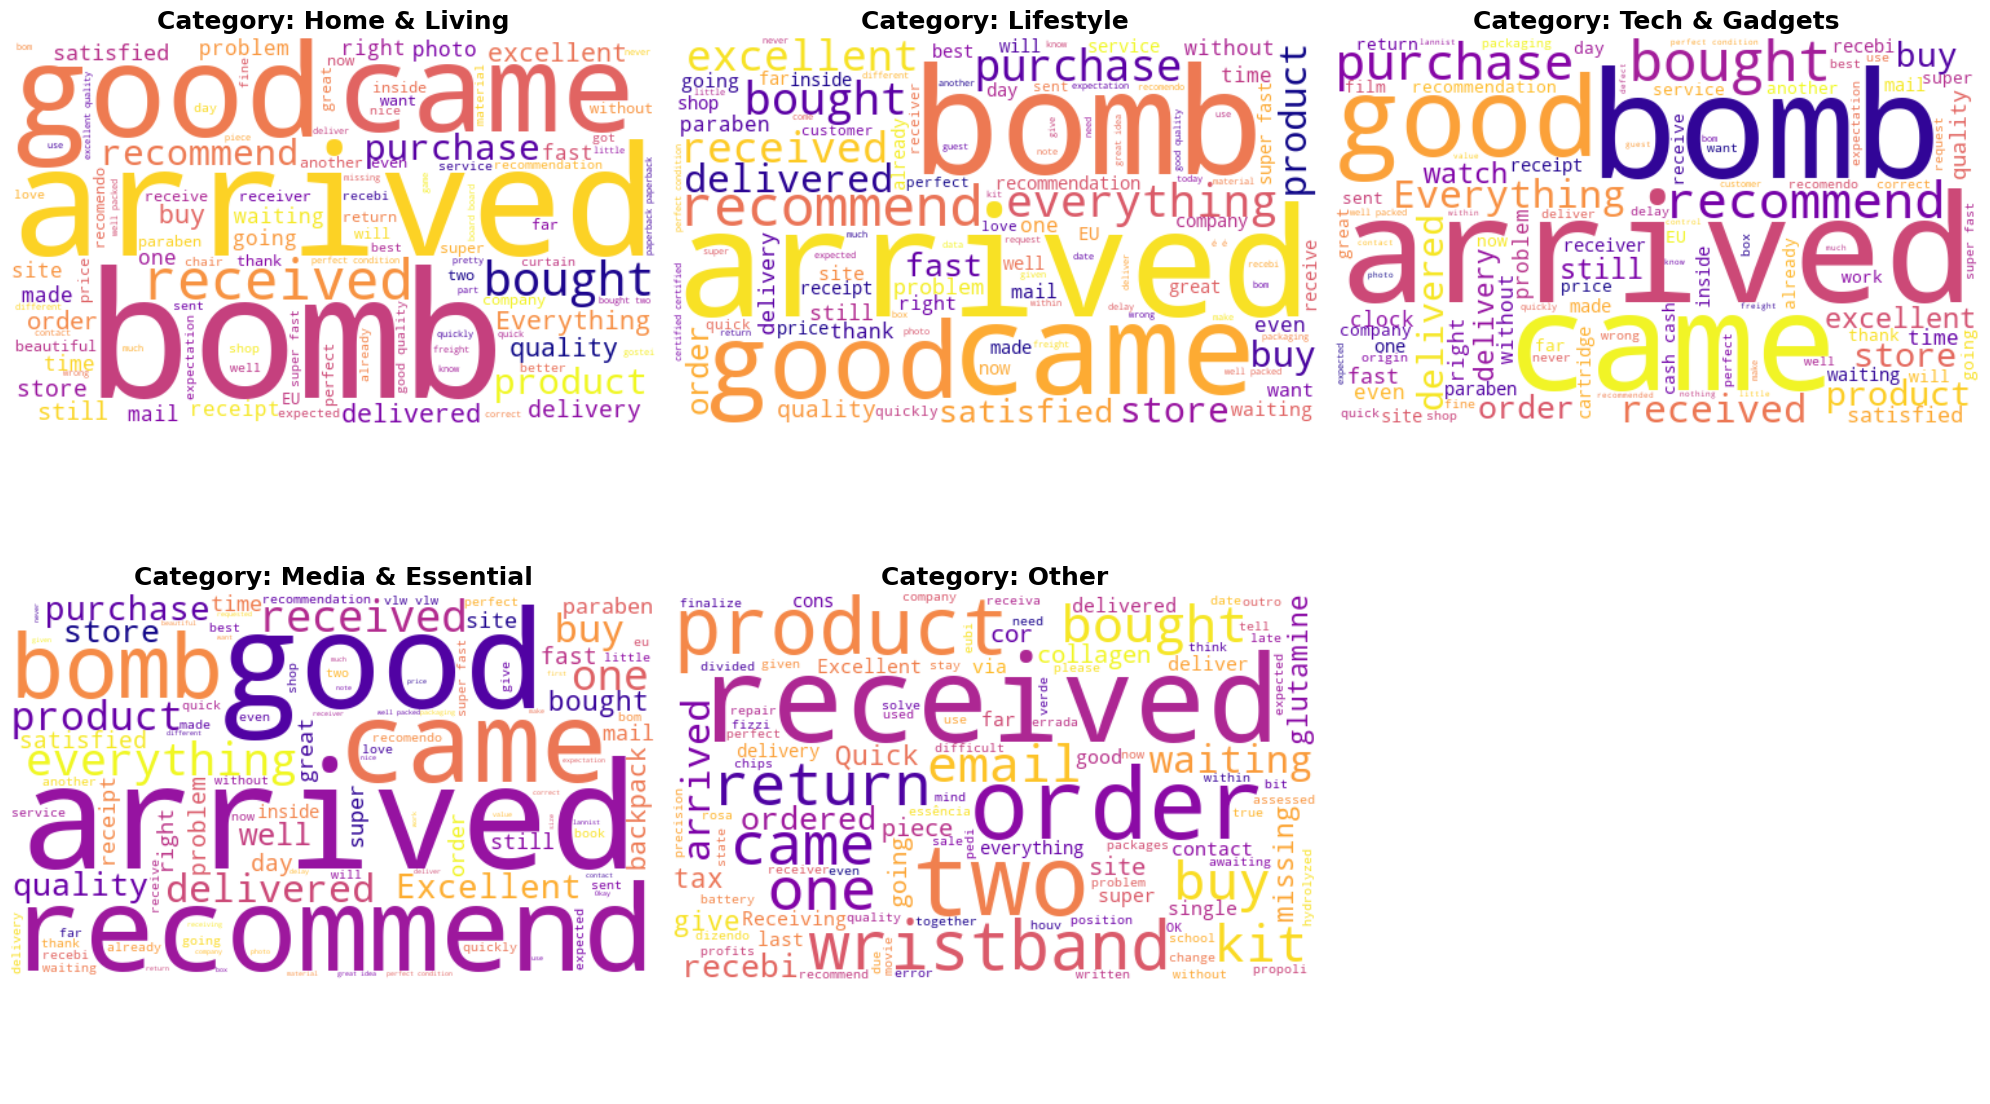

In [9]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math

categories = train_clean['macro_category'].unique()
num_categories = len(categories)

cols = 3
rows = math.ceil(num_categories / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows))
axes = axes.flatten()

for i, cat in enumerate(categories):
    subset = train_clean[train_clean['macro_category'] == cat]
    
    text = " ".join(review for review in subset['english_review_text'].astype(str))
    
    if len(text.strip()) > 0:
        wc = WordCloud(
            width=500, 
            height=300, 
            background_color='white',
            max_words=100,
            colormap='plasma' 
        ).generate(text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'Category: {cat}', fontsize=18, fontweight='bold')
    else:
        axes[i].text(0.5, 0.5, f'No Data for {cat}', ha='center')
        
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd

# 1. View rows containing missing values (NaN) that will be removed by dropna()
nan_rows = train_clean[train_clean['review_text'].isna() | train_clean['english_review_text'].isna()]

print("=== 📌 Rows with Missing Values (NaN) - To be removed by dropna() ===")
if not nan_rows.empty:
    print(f"Total rows found with NaN: {len(nan_rows)}")
    # Display the first 5 rows for inspection
    print(nan_rows[['review_text', 'english_review_text']].head())
else:
    print("No missing values (NaN) found.")

print("\n" + "="*60 + "\n")

# 2. View rows containing non-string data types (e.g., pure numbers like 5, 100)
# We exclude rows that are already NaN and filter for data types that are not 'str'
non_string_rows = train_clean[
    ((train_clean['review_text'].apply(lambda x: type(x) is not str)) & train_clean['review_text'].notna()) |
    ((train_clean['english_review_text'].apply(lambda x: type(x) is not str)) & train_clean['english_review_text'].notna())
]

print("=== 📌 Rows with Non-String Types - To be converted using .astype(str) ===")
if not non_string_rows.empty:
    print(f"Total rows found with non-string types: {len(non_string_rows)}")
    
    # Peek at the first row and its specific Python data type
    first_row = non_string_rows.iloc[0]
    print(f"Example Row data:")
    print(f"  - PT Review: {first_row['review_text']} (Type: {type(first_row['review_text']).__name__})")
    print(f"  - EN Review: {first_row['english_review_text']} (Type: {type(first_row['english_review_text']).__name__})")
else:
    print("All non-null reviews are already properly formatted as strings.")


=== 📌 Rows with Missing Values (NaN) - To be removed by dropna() ===
Total rows found with NaN: 173
    review_text english_review_text
247         NaN                 NaN
318         NaN                 NaN
357         NaN                 NaN
800         NaN                 NaN
931         NaN                 NaN


=== 📌 Rows with Non-String Types - To be converted using .astype(str) ===
All non-null reviews are already properly formatted as strings.


In [11]:
import torch
from sentence_transformers import SentenceTransformer

model_sim = SentenceTransformer('sentence-transformers/LaBSE')

train_clean_filtered = train_clean.dropna(subset=['review_text', 'english_review_text'])

train_clean_filtered['review_text'] = train_clean_filtered['review_text'].astype(str)
train_clean_filtered['english_review_text'] = train_clean_filtered['english_review_text'].astype(str)

sample = train_clean_filtered.sample(500, random_state=42) 
portuguese_texts = sample['review_text'].tolist()
english_texts = sample['english_review_text'].tolist()

embeddings_pt = torch.tensor(model_sim.encode(portuguese_texts))
embeddings_en = torch.tensor(model_sim.encode(english_texts))

scores = torch.nn.functional.cosine_similarity(embeddings_pt, embeddings_en, dim=1)
avg_score = scores.mean().item()

print(f"Average Semantic Similarity Score: {avg_score:.4f} (The closer to 1, the better)")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/LaBSE
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\user\AppData\Local\Temp\ipykernel_3472\2169834216.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_clean_filtered['review_text'] = train_clean_filtered['review_text'].astype(str)
C:\Users\user\AppData\Local\Temp\ipykernel_3472\2169834216.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

Average Semantic Similarity Score: 0.6595 (The closer to 1, the better)


In [12]:
df_all = pd.concat([train_clean, test_clean], axis=0).reset_index(drop=True)
low_score_df = df_all[df_all['review_score'] <= 2]

In [13]:
low_score_df = low_score_df.dropna(subset=['english_review_text'])

# 2. Re-generate your clean document list (casting to string just to be safe)
low_score_docs = low_score_df['english_review_text'].astype(str).tolist()

# 3. Double-check that the 16 'nan' strings are completely gone
print("=== 📌 Clean-up Verification ===")
print(f"Merge complete. A total of {len(low_score_docs)} negative reviews are ready for topic modeling.")
print(f"Number of 'nan' strings remaining: {sum(1 for doc in low_score_docs if doc.lower() == 'nan')}")

=== 📌 Clean-up Verification ===
Merge complete. A total of 9853 negative reviews are ready for topic modeling.
Number of 'nan' strings remaining: 0


In [14]:
category_counts = df_all['macro_category'].value_counts()
print(category_counts)

macro_category
Home & Living        15006
Lifestyle            12697
Tech & Gadgets        8746
Media & Essential     2656
Other                   35
Name: count, dtype: int64


## 📝 Note on Topic Modeling Evolution & Replication

### ⚠️ Replication Context
During the initial exploratory phase, a 4-topic configuration was identified containing the following themes:
* `Fulfillment & Returns`
* `Customer Anxiety`
* `Product Specification`
* `Installation Issues`

Because a fixed random seed was not initially assigned to the stochastic UMAP dimensional reduction layer, **this exact 4-cluster configuration could not be perfectly replicated** upon subsequent notebook executions. 

### 🎯 Optimization & Enhanced Granularity
Rather than forcing a restoration of the original fuzzier categories, the pipeline was rebuilt utilizing a strictly locked random state (`random_state=42`) to guarantee future end-to-end auditability. 

During this stable re-runs, expanding the unsupervised architecture to a **5-topic model** revealed a significantly more actionable and granular distribution of customer pain points. Broad terms like *"Customer Anxiety"* and *"Product Specification"* naturally split into high-value product-specific defects and severe compliance issues.

### 🔄 Topic Mapping Alignment

The model has been finalized around the following **5 deterministic business domains**:

| Legacy Unreplicated Topic | Final Reproducible Business Label | Strategic Analytics Focus |
| :--- | :--- | :--- |
| **Fulfillment & Returns** | `Logistics: Delayed & Lost Shipments` | Severe delays, missing packages, and critical delivery backlogs causing churn. |
| **Customer Anxiety** | `Logistics: Invoice & Order Inquiries` | Upstream post-purchase confusion, including invoice mismatches and missing email responses. |
| **Product Specification** | `Product: Incorrect Specs & Volume Shortage` | Highly technical complaints regarding metric shortages (ML / CM) and downsizing. |
| **Installation Issues** | `Product: Watch Defects & Discrepancies` | Pinpointed category quality cluster uncovering systemic damage and wrong variants in timepieces. |
| *New Sub-Segment* | `Marketing: Deceptive & False Advertising` | Severe legal and compliance friction regarding consumer trust, broken kits, and deceptive imagery. |

*Moving forward, all downstream reporting, stacked bar visualizations, and text cloud generators will strictly reference this audited, reproducible 5-topic mapping.*


In [18]:
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from umap import UMAP  # 🎯 Import UMAP to lock the seed
import torch
import pandas as pd

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

# 🎯 Define UMAP with a fixed random seed to guarantee reproducible clusters
umap_model = UMAP(
    n_neighbors=15, 
    n_components=5, 
    min_dist=0.0, 
    metric='cosine', 
    random_state=42  # 🔒 Fixed seed number
)

custom_stopwords = ["the", "to", "and", "is", "it", "of", "for", "was", "my", "bought", "product", "received", "in", "with", "have", "so", "but"]
vectorizer_model = CountVectorizer(stop_words=custom_stopwords, ngram_range=(1, 2))

representation_model = KeyBERTInspired()

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,  # 🎯 Pass the locked UMAP model here
    vectorizer_model=vectorizer_model,
    representation_model=representation_model,
    nr_topics=10, 
    calculate_probabilities=False, 
    verbose=True
)

topics, _ = topic_model.fit_transform(low_score_docs)

print("\n--- Final Meaningful Topics ---")
print(topic_model.get_topic_info().head(11))



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-09-23 09:57:37,254 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/291 [00:00<?, ?it/s]

2026-09-23 09:57:54,486 - BERTopic - Embedding - Completed ✓
2026-09-23 09:57:54,486 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-23 09:58:07,426 - BERTopic - Dimensionality - Completed ✓
2026-09-23 09:58:07,427 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-23 09:58:07,713 - BERTopic - Cluster - Completed ✓
2026-09-23 09:58:07,714 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-23 09:58:08,004 - BERTopic - Representation - Completed ✓
2026-09-23 09:58:08,005 - BERTopic - Topic reduction - Reducing number of topics
2026-09-23 09:58:08,028 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-23 09:58:08,828 - BERTopic - Representation - Completed ✓
2026-09-23 09:58:08,831 - BERTopic - Topic reduction - Reduced number of topics from 163 to 10



--- Final Meaningful Topics ---
   Topic  Count  \
0     -1   3534   
1      0   4790   
2      1    564   
3      2    216   
4      3     67   
5      4     31   
6      5     28   
7      6     25   
8      7     24   
9      8     22   

                                                                                  Name  \
0                                                 -1_receipt_delivered_receive_arrived   
1                                                 0_delivered_receipt_delivery_arrived   
2                                            1_faith given_you faith_faith_faith still   
3                                          2_wristwatch_watches_two watches_watch came   
4             3_authorities still_authorities back_hands authorities_authorities going   
5                      4_participants zero_participants no_no comment_any participants   
6                                               5_demor demor_demor_do demor_demor has   
7  6_deceptive propaganda_propaganda 

In [19]:
original_topics_count = len(topic_model.topic_labels_) 
print(f"Before reducing to 10, the model originally discovered {original_topics_count} topics automatically.")

Before reducing to 10, the model originally discovered 10 topics automatically.


In [29]:
low_score_df['topic_id'] = topics 

target_topics = [-1, 0, 2, 6, 8]
important_segment = low_score_df[low_score_df['topic_id'].isin(target_topics)].copy()

topic_mapping = {
    -1: "Logistics: Invoice & Order Inquiries",
    0: "Logistics: Delayed & Lost Shipments",
    2: "Product: Watch Defects & Discrepancies",
    6: "Marketing: Deceptive & False Advertising",  
    8: "Product: Incorrect Specs & Volume Shortage"   
}
important_segment['Theme'] = important_segment['topic_id'].map(topic_mapping)


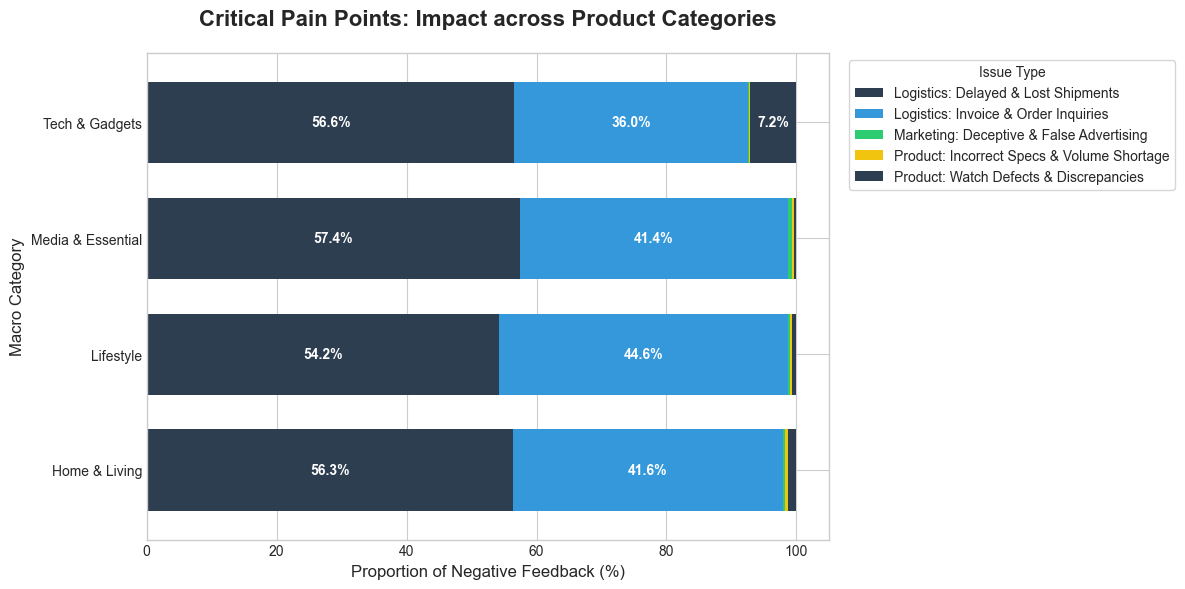

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

category_topic_dist = pd.crosstab(important_segment['macro_category'], important_segment['Theme'])
category_topic_pct = category_topic_dist.div(category_topic_dist.sum(1), axis=0) * 100

filtered_pct = category_topic_pct.drop(index='Other', errors='ignore')

plt.style.use('seaborn-v0_8-whitegrid') 
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#2c3e50', '#3498db', '#2ecc71', '#f1c40f']
filtered_pct.plot(kind='barh', stacked=True, color=colors, ax=ax, width=0.7)

plt.title('Critical Pain Points: Impact across Product Categories', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Proportion of Negative Feedback (%)', fontsize=12)
plt.ylabel('Macro Category', fontsize=12)
plt.legend(title='Issue Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)

for p in ax.patches:
    width = p.get_width()
    if width > 5: 
        ax.text(p.get_x() + width/2, p.get_y() + p.get_height()/2, 
                f'{width:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


In [31]:
diagnosis_matrix = category_topic_pct.drop(index='Other', errors='ignore').copy()

styled_matrix = diagnosis_matrix.style.background_gradient(cmap='Blues', axis=1)\
    .format("{:.2f}%")\
    .set_caption("Negative Review Diagnosis Matrix: Issues by Category")

print("--- Customer Pain Point Diagnosis Matrix ---")
print(diagnosis_matrix.round(2))

styled_matrix

--- Customer Pain Point Diagnosis Matrix ---
Theme              Logistics: Delayed & Lost Shipments  \
macro_category                                           
Home & Living                                    56.34   
Lifestyle                                        54.18   
Media & Essential                                57.41   
Tech & Gadgets                                   56.61   

Theme              Logistics: Invoice & Order Inquiries  \
macro_category                                            
Home & Living                                     41.56   
Lifestyle                                         44.61   
Media & Essential                                 41.36   
Tech & Gadgets                                    35.99   

Theme              Marketing: Deceptive & False Advertising  \
macro_category                                                
Home & Living                                          0.35   
Lifestyle                                              0.27   

Theme,Logistics: Delayed & Lost Shipments,Logistics: Invoice & Order Inquiries,Marketing: Deceptive & False Advertising,Product: Incorrect Specs & Volume Shortage,Product: Watch Defects & Discrepancies
macro_category,,,,,
Home & Living,56.34%,41.56%,0.35%,0.41%,1.34%
Lifestyle,54.18%,44.61%,0.27%,0.23%,0.70%
Media & Essential,57.41%,41.36%,0.62%,0.21%,0.41%
Tech & Gadgets,56.61%,35.99%,0.14%,0.05%,7.21%


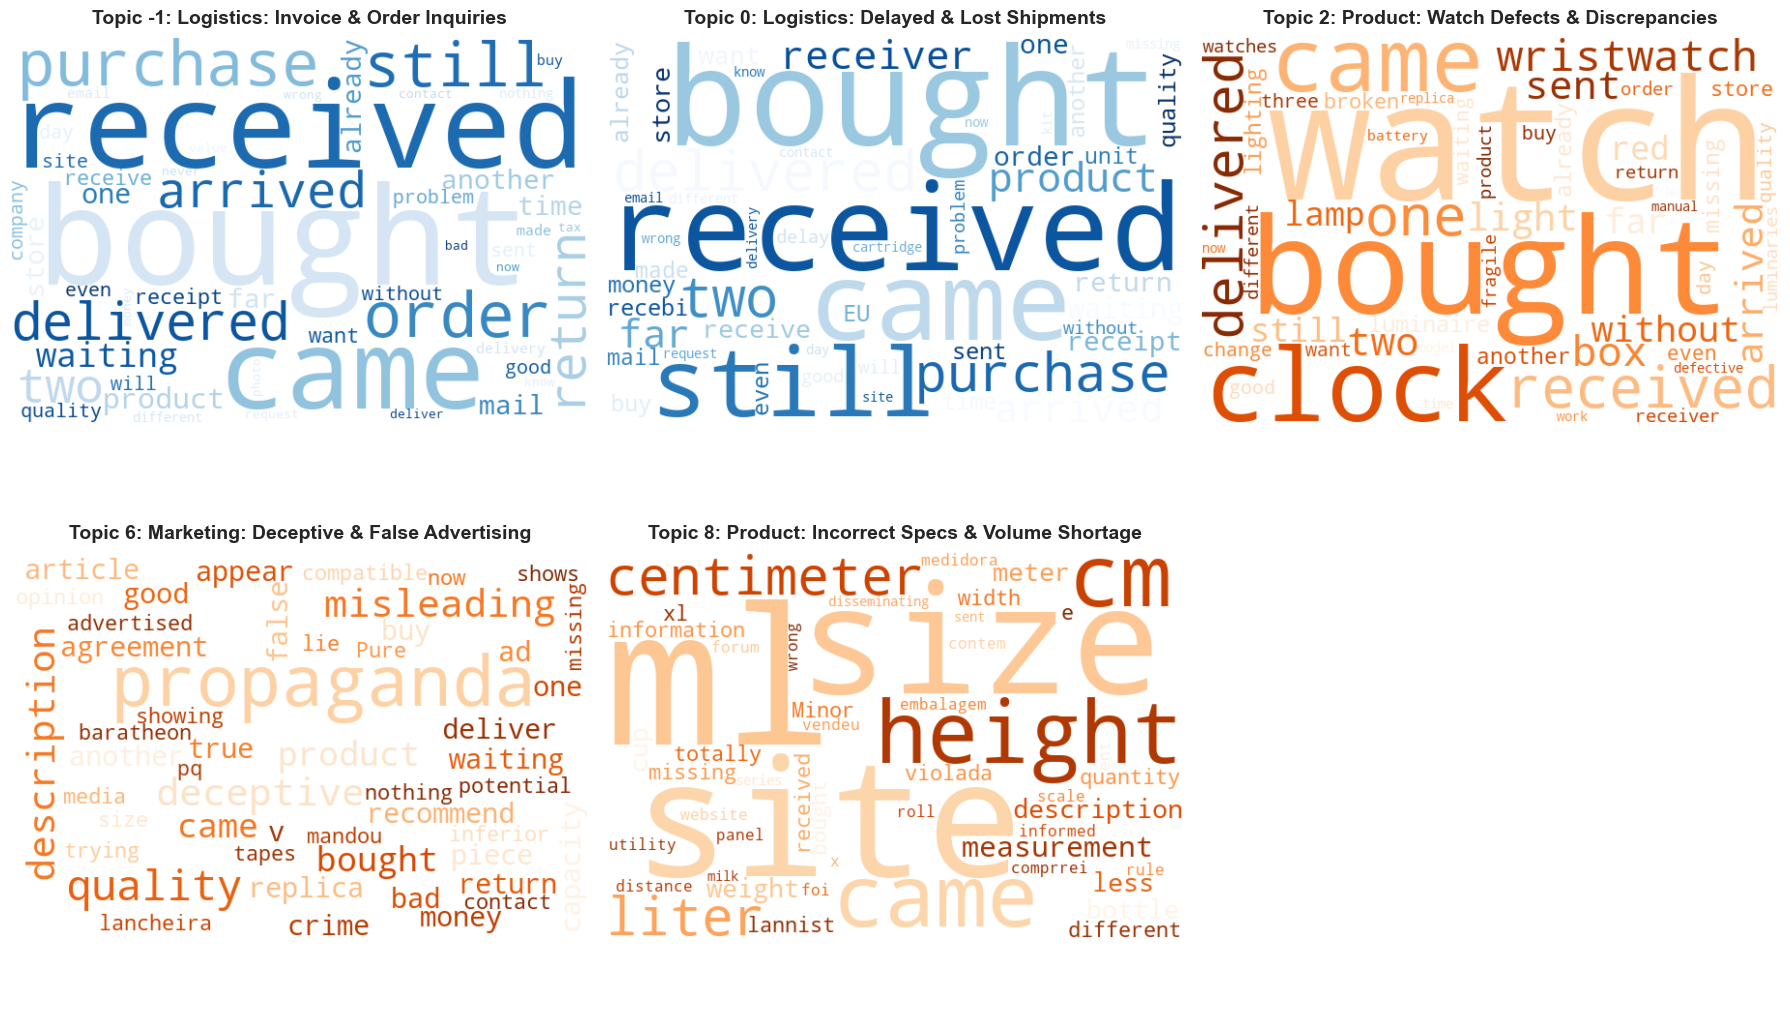

In [32]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. 🎯 Tweak to 2 rows and 3 columns to easily accommodate 5 topics (2 * 3 = 6 slots)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, t_id in enumerate(target_topics):
    # Filter documents belonging to the current topic
    subset_docs = [doc for j, doc in enumerate(low_score_docs) if topics[j] == t_id]
    text = " ".join(subset_docs)
    
    if len(text.strip()) > 0:
        # Categorize colormap based on theme types
        color_map = 'Blues' if t_id in [-1, 0] else 'Oranges'
        
        wc = WordCloud(
            width=600, height=400, 
            background_color='white',
            colormap=color_map,
            max_words=50,
            collocations=False
        ).generate(text)
        
        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f"Topic {t_id}: {topic_mapping[t_id]}", fontsize=14, fontweight='bold', pad=10)
    else:
        axes[i].text(0.5, 0.5, 'No Text Data', ha='center', va='center')
        
    axes[i].axis('off')

# 2. 🎯 Clean up the empty 6th plot so it doesn't display raw empty axis lines
for j in range(len(target_topics), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()
